## **Lab Assignment 1**

<font color='purple'>**K-NN regression**</font>

<font color='blue'>Description:</font> Neighbors-based regression can be used in cases where the data labels are continuous rather than discrete variables. The label assigned to a query point is computed based on the mean of the labels of its nearest neighbors.

<font color='blue'>scikit-learn implements two different neighbors regressors: </font>  
1. ***KNeighborsRegressor*** implements learning based on the K nearest neighbors of each query point, where K is an integer value specified by the user.
2. ***RadiusNeighborsRegressor*** implements learning based on the neighbors within a fixed radius of the query point, where is a floating-point value specified by the user.

<font color='red'>**NOTE**</font>

The basic nearest neighbors regression uses ```uniform weights:``` that is, each point in the local neighborhood contributes uniformly to the classification of a query point. Under some circumstances, it can be advantageous to ```weight points``` such that nearby points contribute more to the regression than faraway points. This can be accomplished through the ```weights keyword```. The default value, ```weights = 'uniform'```, assigns equal weights to all points. ```weights = 'distance'``` assigns weights proportional to the inverse of the distance from the query point.

**Alternatively, a user-defined function of the distance can be supplied, which will be used to compute the weights.**


### <font color='blue'>Objective: </font>

In this assignment, you will implement and evaluate a K-Nearest Neighbors (KNN) regression model using a toy dataset generated with scikit-learn. You will implement with scikit-learn's built-in KNN regression and analyze the performance.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Task - 1:
Dataset creation using make_regression of scikit-learn [Mark - 0]



In [2]:
# Creating regression dataset
from sklearn.datasets import make_regression

# Creating a toy regression dataset with 5 features
x_gen, y_gen = make_regression(n_samples=1000, n_features=5, noise=0.1, random_state=42)

# Combine the features and target into one DataFrame
df = pd.DataFrame(x_gen, columns=[f'Feature_{i}' for i in range(1, 6)])
df['target'] = y_gen

# Save the DataFrame to a CSV file
df.to_csv('regression_dataset.csv', index=False)
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,target
0,2.056544,0.606851,0.482688,-1.130888,0.420094,74.905613
1,-0.799192,-0.645964,-0.182896,-0.482744,1.374876,-41.649588
2,1.076007,-0.796026,-0.751969,0.021312,-0.319054,-24.182866
3,-0.103255,-0.828497,1.489863,-1.643189,-1.600904,-87.094505
4,-2.063403,0.503252,-0.645572,-0.317350,-1.661083,-86.122029


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  1000 non-null   float64
 1   Feature_2  1000 non-null   float64
 2   Feature_3  1000 non-null   float64
 3   Feature_4  1000 non-null   float64
 4   Feature_5  1000 non-null   float64
 5   target     1000 non-null   float64
dtypes: float64(6)
memory usage: 47.0 KB


In [4]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.006531,0.004543,0.001297,0.032846,-0.017207,0.897721
std,0.959842,1.005321,0.999219,0.988835,1.029248,64.722278
min,-3.007632,-3.241267,-3.170426,-3.176704,-2.940389,-223.083437
25%,-0.649871,-0.693862,-0.645736,-0.607606,-0.711821,-41.690573
50%,0.064768,0.022395,0.027885,-0.006855,-0.034162,2.208131
75%,0.679256,0.642029,0.649413,0.690789,0.663808,46.333821
max,3.078881,3.152057,3.926238,3.852731,3.243093,173.137959


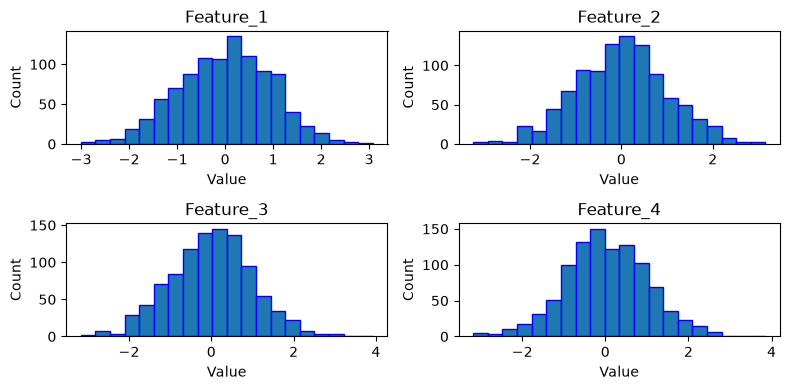

In [5]:
num_features = df.columns
rows = 2
cols = 2

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(8, 4))
axes = axes.flatten()

# Plot each feature
# enumerate -> (i, arr[i])
for i, feature in enumerate(df.columns[: rows * cols]):
    axes[i].hist(df[feature].dropna(), bins=20, edgecolor='blue')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
  
# auto space adjustment to prevent overlap  
plt.tight_layout()

**NOTE** - As the range of all 5 features are comparable, all within -3.25 to 4 with mean nearly 0 and standard deviation nearly 1, ***scaling is not required***. 

In [6]:
x = df.drop(columns='target').to_numpy()
y = df['target'].to_numpy()

print("Feature shape:", x.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 5)
Target shape: (1000,)


#### Task - 2:
Two K-NN regressor implementations (from scratch)
1. Average of K-nearest neighbors [Marks - 5]
2. Weighted average of k nearest neighbors, with weights being inverse of distances from the k neighbors [Marks - 5]

In [7]:
# Some common distance metrics
def minkowski_distance(x, y, p=2):
    return np.sum(np.abs(x - y) ** p) ** (1 / p)

def cosine_similarity(x, y):
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))

In [8]:
# Solution code
# 1) Average of K-nearest neighbors

class KNN_Regressor:
    def __init__(self, k=3, distance_metric='euclidean', p=2):
        self.k = k
        self.distance_metric = distance_metric
        self.p = p  # parameter for Minkowski distance
        
    def fit_knn(self, x_train, y_train):       
        self.x_train = x_train
        self.y_train = y_train
        
    def _compute_distance(self, x):
        if self.distance_metric == 'minkowski':
            distances = [minkowski_distance(x, x_train, p=self.p) for x_train in self.x_train]
        elif self.distance_metric == 'cosine':
            distances = [cosine_similarity(x, x_train) for x_train in self.x_train]
        elif self.distance_metric == 'chebyshev':
            distances = [chebyshev_distance(x, x_train) for x_train in self.x_train]
        else:
            raise ValueError('Unsupported Distance Metric!')
        return distances
    
    def predict(self, x_test):
        predictions = []
        for x in x_test:
            distances = self._compute_distance(x)
            if self.distance_metric == 'cosine':
                # fetch indices with k highest values
                k_indices = np.argsort(distances)[-self.k:]
            else:
                # fetch indices with k lowest values
                k_indices = np.argsort(distances)[:self.k]                
            # fetch its corresponding values
            k_nearest_values = [self.y_train[i] for i in k_indices]
            # assign the value as average of k nearest values
            prediction = np.mean(k_nearest_values)
            predictions.append(prediction)
        return predictions
    

In [9]:
# Solution code
# 2) Weighted average of k nearest neighbors, with weights being inverse of distances from the k neighbors

class KNN_Weighted_Regressor:
    def __init__(self, k=3, distance_metric='euclidean', p=2):
        self.k = k
        self.distance_metric = distance_metric
        self.p = p  # parameter for Minkowski distance
        
    def fit_knn(self, x_train, y_train):       
        self.x_train = x_train
        self.y_train = y_train
        
    def _compute_distance(self, x):
        if self.distance_metric == 'minkowski':
            distances = [minkowski_distance(x, x_train, p=self.p) for x_train in self.x_train]
        elif self.distance_metric == 'cosine':
            distances = [cosine_similarity(x, x_train) for x_train in self.x_train]
        elif self.distance_metric == 'chebyshev':
            distances = [chebyshev_distance(x, x_train) for x_train in self.x_train]
        else:
            raise ValueError('Unsupported Distance Metric!')
        return distances
    
    def predict(self, x_test):
        predictions = []
        for x in x_test:
            distances = self._compute_distance(x)           
            if self.distance_metric == 'cosine':
                # fetch indices with k highest values
                k_indices = np.argsort(distances)[-self.k:]
                # weight = distance
                weights = [distances[i] for i in k_indices]
                # fetch its corresponding values
                k_nearest_values = [self.y_train[i] for i in k_indices]           
                # assign the value as weighted average of k nearest values (avoid division by 0 error)
                weight_sum = np.sum(weights)
                if weight_sum == 0:
                    prediction = np.mean(k_nearest_values)
                else:
                    prediction = np.dot(weights, k_nearest_values) / weight_sum
            else:
                # fetch indices with k lowest values
                k_indices = np.argsort(distances)[:self.k]   
                if distances[k_indices[0]] == 0:
                    # found exact match (also avoids division by 0 error)
                    prediction = self.y_train[k_indices[0]]  
                else:
                    # weight = 1 / distance
                    weights = [1 / distances[i] for i in k_indices]                
                    # fetch its corresponding values
                    k_nearest_values = [self.y_train[i] for i in k_indices]           
                    # assign the value as weighted average of k nearest values            
                    prediction = np.dot(weights, k_nearest_values) / np.sum(weights)       
            predictions.append(prediction)
        return predictions 

#### Task - 3:
Plot regression metric (mean squared error) against different values of k ``` {3, 7, 11}``` and different distance measures ```{p=2, p=1, p=5}```and report the k value and distance measure combination that gave the best performance (lowest MSE) [Marks - 4]

In [10]:
# Train and Test split of dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

print("Train dataset dimensions:", len(x_train), len(y_train))
print("Test dataset dimensions:", len(x_test), len(y_test))

Train dataset dimensions: 750 750
Test dataset dimensions: 250 250


In [11]:
# Solution code
# 1) Average of K-nearest neighbors
from sklearn.metrics import mean_squared_error

k_values = [3, 7, 11]
p_values = [2, 1, 5]
results = []

for k in k_values:
    for p in p_values:
        my_knn = KNN_Regressor(k=k, distance_metric='minkowski', p=p)
        my_knn.fit_knn(x_train=x_train, y_train=y_train)
        y_predictions = my_knn.predict(x_test)
        mse = mean_squared_error(y_true=y_test, y_pred=y_predictions)
        results.append({'k' : k, 'p' : p, 'mse' : mse})
        
results_df = pd.DataFrame(results)
print(results_df)

    k  p         mse
0   3  2  279.037336
1   3  1  322.584991
2   3  5  329.636974
3   7  2  305.435342
4   7  1  334.943610
5   7  5  278.366918
6  11  2  331.557432
7  11  1  394.845217
8  11  5  315.825008


Best k: 7
Best p: 5
Lowest MSE: 278.37


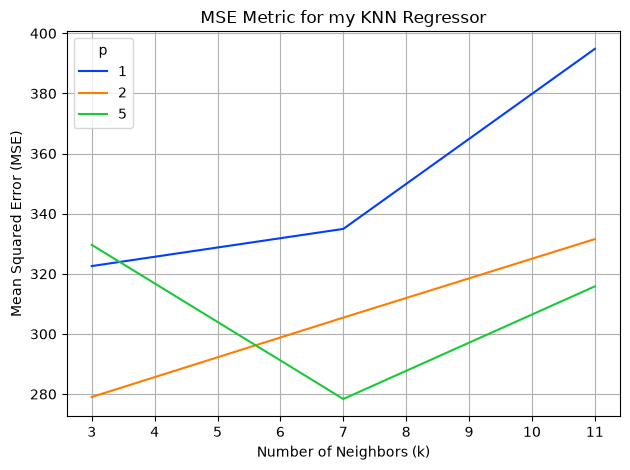

In [12]:
sns.lineplot(data=results_df, x='k', y='mse', hue='p', palette='bright')
plt.grid(True)
plt.title("MSE Metric for my KNN Regressor")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.tight_layout()
plt.savefig('mse_plots/my_knn.png')

best_param_my_knn = results_df.loc[results_df['mse'].idxmin()]
print(f"Best k: {best_param_my_knn['k']:.0f}")
print(f"Best p: {best_param_my_knn['p']:.0f}")
print(f"Lowest MSE: {best_param_my_knn['mse']:.2f}")

In [13]:
# Solution code
# 2) Weighted average of k nearest neighbors, with weights being inverse of distances from the k neighbors
from sklearn.metrics import mean_squared_error

k_values = [3, 7, 11]
p_values = [2, 1, 5]
results = []

for k in k_values:
    for p in p_values:
        my_wknn = KNN_Weighted_Regressor(k=k, distance_metric='minkowski', p=p)
        my_wknn.fit_knn(x_train=x_train, y_train=y_train)
        y_predictions = my_wknn.predict(x_test)
        mse = mean_squared_error(y_true=y_test, y_pred=y_predictions)
        results.append({'k' : k, 'p' : p, 'mse' : mse})
        
results_df = pd.DataFrame(results)
print(results_df)

    k  p         mse
0   3  2  262.543514
1   3  1  301.916328
2   3  5  303.614054
3   7  2  276.018722
4   7  1  304.442682
5   7  5  260.002680
6  11  2  299.964072
7  11  1  357.747488
8  11  5  289.096566


Best k: 7
Best p: 5
Lowest MSE: 260.00


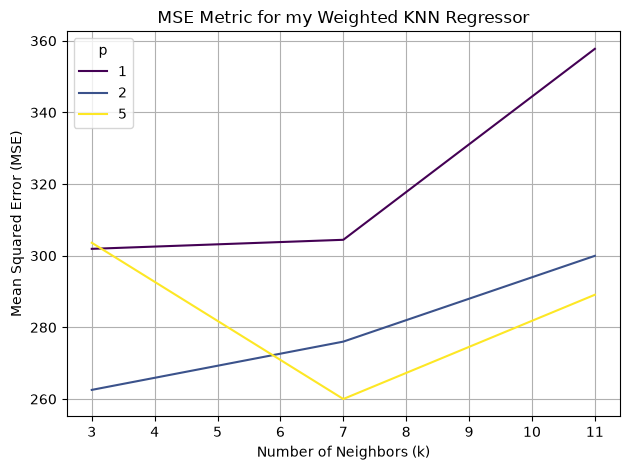

In [14]:
sns.lineplot(data=results_df, x='k', y='mse', hue='p', palette='viridis')
plt.grid(True)
plt.title("MSE Metric for my Weighted KNN Regressor")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.tight_layout()
plt.savefig('mse_plots/my_wknn.png')

best_param_my_wknn = results_df.loc[results_df['mse'].idxmin()]
print(f"Best k: {best_param_my_wknn['k']:.0f}")
print(f"Best p: {best_param_my_wknn['p']:.0f}")
print(f"Lowest MSE: {best_param_my_wknn['mse']:.2f}")

#### Task - 4:
Implement KNN regression using scikit-learn, with the same values of k and p as above

##### Note - one argument of scikit-learn KNN is ```algorithm='auto'``` and acceptable values are ```{'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto' ```. For this task use ```'brute'``` setting.

[Marks - 4]

In [15]:
# Solution code
# 1) Average of K-nearest neighbors

from sklearn.neighbors import KNeighborsRegressor

k_values = [3, 7, 11]
p_values = [2, 1, 5]
results = []

for k in k_values:
    for p in p_values:
        sk_knn = KNeighborsRegressor(n_neighbors=k, metric='minkowski', p=p, weights='uniform', algorithm='brute')
        sk_knn.fit(X=x_train, y=y_train)
        y_predictions = sk_knn.predict(X=x_test)
        mse = mean_squared_error(y_true=y_test, y_pred=y_predictions)
        results.append({'k' : k, 'p' : p, 'mse' : mse})
        
results_df = pd.DataFrame(results)
print(results_df)

    k  p         mse
0   3  2  279.037336
1   3  1  322.584991
2   3  5  329.636974
3   7  2  305.435342
4   7  1  334.943610
5   7  5  278.366918
6  11  2  331.557432
7  11  1  394.845217
8  11  5  315.825008


Best k: 7
Best p: 5
Lowest MSE: 278.37


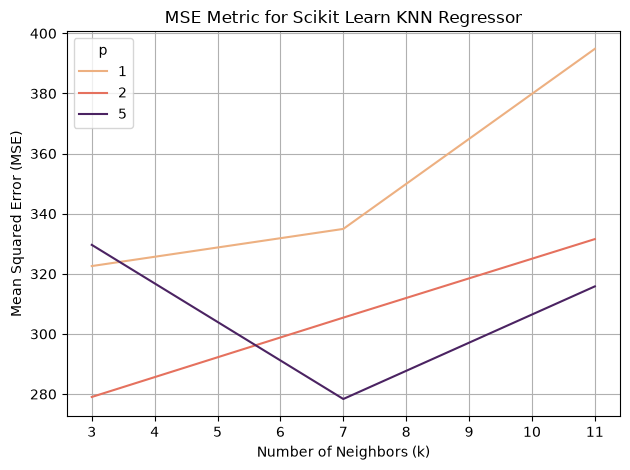

In [16]:
sns.lineplot(data=results_df, x='k', y='mse', hue='p', palette='flare')
plt.grid(True)
plt.title("MSE Metric for Scikit Learn KNN Regressor")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.tight_layout()
plt.savefig('mse_plots/sk_knn.png')

best_param_sk_knn = results_df.loc[results_df['mse'].idxmin()]
print(f"Best k: {best_param_sk_knn['k']:.0f}")
print(f"Best p: {best_param_sk_knn['p']:.0f}")
print(f"Lowest MSE: {best_param_sk_knn['mse']:.2f}")

In [17]:
# Solution code
# 2) Weighted average of k nearest neighbors, with weights being inverse of distances from the k neighbors

k_values = [3, 7, 11]
p_values = [2, 1, 5]
results = []

for k in k_values:
    for p in p_values:
        sk_wknn = KNeighborsRegressor(n_neighbors=k, metric='minkowski', p=p, weights='distance', algorithm='brute')
        sk_wknn.fit(X=x_train, y=y_train)
        y_predictions = sk_wknn.predict(X=x_test)
        mse = mean_squared_error(y_true=y_test, y_pred=y_predictions)
        results.append({'k' : k, 'p' : p, 'mse' : mse})
        
results_df = pd.DataFrame(results)
print(results_df)

    k  p         mse
0   3  2  262.543514
1   3  1  301.916328
2   3  5  303.614054
3   7  2  276.018722
4   7  1  304.442682
5   7  5  260.002680
6  11  2  299.964072
7  11  1  357.747488
8  11  5  289.096566


Best k: 7
Best p: 5
Lowest MSE: 260.00


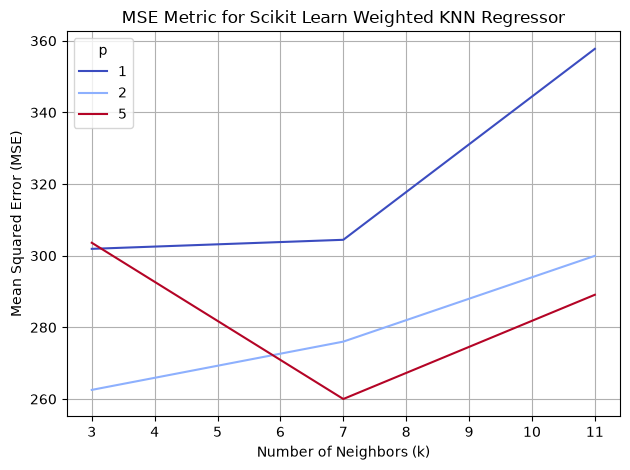

In [18]:
sns.lineplot(data=results_df, x='k', y='mse', hue='p', palette='coolwarm')
plt.grid(True)
plt.title("MSE Metric for Scikit Learn Weighted KNN Regressor")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.tight_layout()
plt.savefig('mse_plots/sk_wknn.png')

best_param_sk_wknn = results_df.loc[results_df['mse'].idxmin()]
print(f"Best k: {best_param_sk_wknn['k']:.0f}")
print(f"Best p: {best_param_sk_wknn['p']:.0f}")
print(f"Lowest MSE: {best_param_sk_wknn['mse']:.2f}")

#### Task - 5:
Comparison with scikit-learn's implementation - Does the optimal values of k and distance metric as well as best performance level of the from scratch implementation match with those given by Sklearn?

[Marks - 2]

In [19]:
# Solution code
summary = {
    'Implementation (Weights)' : 
        ['From Scratch (Uniform)', 'Scikit Learn (Uniform)', 'From Scratch (Distance)', 'Scikit Learn (Distance)'],
    'Optimal k' : 
        [int(best_param_my_knn['k']), int(best_param_sk_knn['k']), int(best_param_my_wknn['k']), int(best_param_sk_wknn['k'])],
    'Optimal p' : 
        [int(best_param_my_knn['p']), int(best_param_sk_knn['p']), int(best_param_my_wknn['p']), int(best_param_sk_wknn['p'])],
    'Lowest MSE': 
        [best_param_my_knn['mse'], best_param_sk_knn['mse'], best_param_my_wknn['mse'], best_param_sk_wknn['mse']],
}

pd.DataFrame(summary)

,Implementation (Weights),Optimal k,Optimal p,Lowest MSE
0,From Scratch (Uniform),7,5,278.366918
1,Scikit Learn (Uniform),7,5,278.366918
2,From Scratch (Distance),7,5,260.002680
3,Scikit Learn (Distance),7,5,260.002680


**Conclusion**

The experimental results show that the optimal values of the number of neighbors-`k` and the Minkowski distance parameter-`p` obtained from the ***from-scratch*** implementation are `identical` to those obtained using ***scikit-learn*** for both uniform and distance-weighted KNN regression. Furthermore, both implementations achieved the `same lowest Mean Squared Error (MSE)`. This confirms that the custom implementation correctly reproduces the behavior and predictive performance of scikit-learn's `KNeighborsRegressor`.